# 23 — Gateway IG Validation: Does the LSTM use what the surrogate claims?

Companion to notebook 22 (Gateway Decision Analysis). For each gateway, runs
Integrated Gradients on prefixes that end there and compares the IG feature
ranking to the surrogate tree's Gini importance.

- **IG vs Surrogate**: validates whether the surrogate explains the right features
- **IG vs Ground Truth**: checks if the model attends to features that actually
  drive real-world decisions
- **Correct vs Incorrect**: reveals which features the model overweights when
  it makes mistakes at gateways

In [1]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import spearmanr

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# --- Load dataset ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
dataset = torch.load(data_path, weights_only=False)

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]

# --- Load model ---
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

model_path = (_current / 'src' / 'notebooks' / 'training_variational_dropout'
              / 'Helpdesk' / 'Helpdesk_full_grad_norm_new_4layer.pkl')
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(model_path), dropout=0.0)
model.eval()

# --- TensorDecoder + activity vocab ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

# --- Predictor ---
from src.interpretability.perturbation_methods.revised_plus.revised_plus import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)

# --- InterpretabilityTool ---
from src.interpretability import InterpretabilityTool

tool = InterpretabilityTool(model, model.data_set_categories, device=torch.device('cpu'))

# Feature indices
ACT_IDX = 0
RES_IDX = 1
VAR_IDX = 2

elapsed_num_idx = decoder.num_features.index('case_elapsed_time')
event_num_idx = decoder.num_features.index('event_elapsed_time')

# All model input features (what IG sees)
cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

print(f'Dataset: {len(dataset)} sequences, seq_len={seq_len}')
print(f'Model input features ({len(ALL_FEATURES)}): {ALL_FEATURES}')

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('VariantIndex', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '12

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


Dataset: 6077 sequences, seq_len=18
Model input features (16): ['Activity', 'Resource', 'VariantIndex', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup', 'case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']


## Identify gateways and collect prefixes

Reproduces the gateway detection and prefix collection from notebook 22.
Also trains surrogate trees so we can compare Gini importances to IG.

In [3]:
MIN_CASES = 50
MIN_BRANCH = 10
MIN_SAMPLES_LEAF = 20
IG_STEPS = 30
MAX_SAMPLES_PER_GATEWAY = 100  # cap IG computation per gateway

# --- Unique cases ---
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)

# --- DFG & decision points ---
dfg = {}
for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    src_start = seq_len - trace_len
    acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

    useful_len = trace_len
    for j in range(trace_len - 1, -1, -1):
        if acts[j].item() == eos_idx:
            useful_len = j
        else:
            break

    act_names = [activity_names[acts[j].item()] for j in range(useful_len)]
    for k in range(len(act_names) - 1):
        edge = (act_names[k], act_names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

successors_map = {}
for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {
    act: succs for act, succs in successors_map.items()
    if len(succs) > 1
}

# --- Collect per-gateway prefix data ---
def extract_features(cat_tuple, num_tuple, decoder):
    act_tensor = cat_tuple[ACT_IDX]
    mask = act_tensor != 0
    prefix_len = int(mask.sum().item())
    if prefix_len == 0:
        return None
    nonzero = mask.nonzero(as_tuple=True)[0]
    start = nonzero[0].item()
    end = start + prefix_len
    acts = act_tensor[start:end]

    last_act = acts[-1].item()
    repeated = 1
    for k in range(len(acts) - 2, -1, -1):
        if acts[k].item() == last_act:
            repeated += 1
        else:
            break

    total_elapsed = decoder.decode_numerical_value('case_elapsed_time', num_tuple[elapsed_num_idx][end - 1].item())
    last_event_dur = decoder.decode_numerical_value('event_elapsed_time', num_tuple[event_num_idx][end - 1].item())
    event_durs = [decoder.decode_numerical_value('event_elapsed_time', num_tuple[event_num_idx][j].item()) for j in range(start, end)]
    mean_event_dur = float(np.mean(event_durs))

    res_tensor = cat_tuple[RES_IDX]
    resources = res_tensor[start:end].tolist()
    n_unique_res = len(set(resources))

    feats = {
        'prefix_length': prefix_len,
        'first_activity': decoder.decode_categorical_value(ACT_IDX, acts[0].item()),
        'n_unique_activities': len(set(acts.tolist())),
        'last_activity_repeated': repeated,
        'total_elapsed_time': total_elapsed,
        'last_event_duration': last_event_dur,
        'mean_event_duration': mean_event_dur,
        'last_resource': decoder.decode_categorical_value(RES_IDX, res_tensor[end - 1].item()),
        'n_unique_resources': n_unique_res,
        'resource_changed': int(n_unique_res > 1),
    }
    for ci, feat_name in enumerate(decoder.cat_features):
        if ci == ACT_IDX:
            continue
        val = cat_tuple[ci][end - 1].item()
        feats[f'last_{feat_name}'] = str(decoder.decode_categorical_value(ci, val))
    for ni, feat_name in enumerate(decoder.num_features):
        feats[f'last_{feat_name}'] = decoder.decode_numerical_value(feat_name, num_tuple[ni][end - 1].item())
    return feats


gateway_data = {}

for gateway_act, succs in decision_points.items():
    qualifying_branches = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying_branches) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    feature_rows, actual_labels, cat_list, num_list = [], [], [], []
    # Also store full tensors for IG
    full_cat_list, full_num_list, prefix_len_list = [], [], []

    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        src_start = seq_len - trace_len
        acts = cat_full[ACT_IDX][src_start:src_start + trace_len]

        useful_len = trace_len
        for j in range(trace_len - 1, -1, -1):
            if acts[j].item() == eos_idx:
                useful_len = j
            else:
                break

        for k in range(useful_len - 1):
            if activity_names[acts[k].item()] != gateway_act:
                continue
            next_act_name = activity_names[acts[k + 1].item()]
            prefix_len = k + 1
            pad_len = seq_len - prefix_len

            cat_prefix = []
            for c in cat_full:
                t = torch.zeros_like(c)
                t[pad_len:] = c[src_start:src_start + prefix_len]
                cat_prefix.append(t)
            num_prefix = []
            for n in num_full:
                t = torch.zeros_like(n)
                t[pad_len:] = n[src_start:src_start + prefix_len]
                num_prefix.append(t)

            feats = extract_features(tuple(cat_prefix), tuple(num_prefix), decoder)
            if feats is not None:
                feature_rows.append(feats)
                actual_labels.append(next_act_name)
                cat_list.append(cat_prefix)
                num_list.append(num_prefix)
                full_cat_list.append(cat_full)
                full_num_list.append(num_full)
                prefix_len_list.append(prefix_len)

    if len(feature_rows) < MIN_CASES:
        continue

    X = pd.DataFrame(feature_rows)
    y_actual = np.array(actual_labels)

    N = len(X)
    cat_batch = [torch.stack([cat_list[i][ci] for i in range(N)]) for ci in range(n_cat)]
    num_stacked = torch.stack([torch.stack(num_list[i], dim=-1) for i in range(N)])
    preds, probs = predictor.predict_batch(cat_batch, num_stacked, batch_size=128)
    y_lstm = np.array([activity_names[p] for p in preds])

    gateway_data[gateway_act] = {
        'X': X, 'y_lstm': y_lstm, 'y_actual': y_actual,
        'successors': succs,
        'full_cat_list': full_cat_list,
        'full_num_list': full_num_list,
        'prefix_len_list': prefix_len_list,
    }

    lstm_acc = (y_lstm == y_actual).mean()
    print(f'{gateway_act}: {N} prefixes, LSTM accuracy={lstm_acc:.3f}')

print(f'\n{len(gateway_data)} qualifying gateways')

Assign seriousness: 995 prefixes, LSTM accuracy=0.509
Take in charge ticket: 996 prefixes, LSTM accuracy=0.674
Resolve ticket: 987 prefixes, LSTM accuracy=0.937
Wait: 279 prefixes, LSTM accuracy=0.631

4 qualifying gateways


## Train surrogate trees (same as notebook 22)

In [4]:
def select_best_depth(X_train, y_train, X_test, y_test, depths=(3, 4, 5, 6, 8, None)):
    results = []
    for depth in depths:
        clf = DecisionTreeClassifier(
            max_depth=depth, min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight='balanced', random_state=42)
        clf.fit(X_train, y_train)
        results.append({'depth': depth, 'test': clf.score(X_test, y_test), 'clf': clf})
    best_idx = 0
    best_test = results[0]['test']
    for i in range(1, len(results)):
        if results[i]['test'] > best_test + 0.02:
            best_idx = i
            best_test = results[i]['test']
    return results[best_idx]['clf']


gateway_results = {}

for gateway_act, gd in gateway_data.items():
    X = gd['X']
    y_lstm = gd['y_lstm']
    y_actual = gd['y_actual']

    cat_cols = [c for c in X.columns if X[c].dtype == 'object']
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_enc = X.copy()
    X_enc[cat_cols] = ord_enc.fit_transform(X[cat_cols].astype(str))

    cat_mappings = {}
    for i, col in enumerate(cat_cols):
        cat_mappings[col] = list(ord_enc.categories_[i])

    try:
        X_train, X_test, y_lstm_train, y_lstm_test, y_actual_train, y_actual_test = \
            train_test_split(X_enc, y_lstm, y_actual, test_size=0.2,
                             random_state=42, stratify=y_actual)
    except ValueError:
        X_train, X_test, y_lstm_train, y_lstm_test, y_actual_train, y_actual_test = \
            train_test_split(X_enc, y_lstm, y_actual, test_size=0.2, random_state=42)

    feature_names = list(X_enc.columns)
    clf_lstm = select_best_depth(X_train, y_lstm_train, X_test, y_lstm_test)
    clf_gt = select_best_depth(X_train, y_actual_train, X_test, y_actual_test)

    gateway_results[gateway_act] = {
        'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
        'feature_names': feature_names,
        'surrogate_fidelity': clf_lstm.score(X_test, y_lstm_test),
        'gt_accuracy': clf_gt.score(X_test, y_actual_test),
        'lstm_accuracy': (y_lstm_test == y_actual_test).mean(),
    }
    gr = gateway_results[gateway_act]
    print(f'{gateway_act}: surr. fidelity={gr["surrogate_fidelity"]:.3f}, '
          f'GT acc={gr["gt_accuracy"]:.3f}, LSTM acc={gr["lstm_accuracy"]:.3f}')

Assign seriousness: surr. fidelity=0.834, GT acc=0.789, LSTM acc=0.508
Take in charge ticket: surr. fidelity=0.825, GT acc=0.665, LSTM acc=0.685
Resolve ticket: surr. fidelity=0.919, GT acc=0.818, LSTM acc=0.934
Wait: surr. fidelity=0.625, GT acc=0.482, LSTM acc=0.589


## Compute IG attributions at each gateway

Runs Integrated Gradients on up to 100 prefixes per gateway. For each prefix,
sums `|attribution|` per model input feature to get a scalar importance score.

In [5]:
ig_results = {}

for gateway_act, gd in gateway_data.items():
    N = len(gd['X'])
    sample_indices = list(range(N))
    if N > MAX_SAMPLES_PER_GATEWAY:
        rng = np.random.RandomState(42)
        sample_indices = rng.choice(N, MAX_SAMPLES_PER_GATEWAY, replace=False).tolist()

    print(f'\n{gateway_act}: computing IG for {len(sample_indices)}/{N} prefixes...')
    rows = []

    for idx in tqdm(sample_indices, desc=gateway_act):
        cat_full = gd['full_cat_list'][idx]
        num_full = gd['full_num_list'][idx]
        prefix_len = gd['prefix_len_list'][idx]

        cat_tensors = [c.clone() for c in cat_full]
        num_tensors = [n.clone() for n in num_full]
        process = (cat_tensors, num_tensors)

        try:
            attr_map = tool.compute_attribution_map(
                process=process,
                prefix_length=prefix_len,
                target='Activity',
                target_class='auto',
                method='integrated_gradients',
                n_steps=IG_STEPS,
                baseline='zero',
            )

            feature_attrs = {}
            for feat in ALL_FEATURES:
                if feat in attr_map.attributions:
                    vals = attr_map.attributions[feat]
                    if hasattr(vals, 'detach'):
                        vals = vals.detach().cpu().numpy()
                    feature_attrs[feat] = float(np.abs(vals).sum())

            feature_attrs['y_lstm'] = gd['y_lstm'][idx]
            feature_attrs['y_actual'] = gd['y_actual'][idx]
            rows.append(feature_attrs)

        except Exception as e:
            print(f'  Error at index {idx}: {e}')
            continue

    if rows:
        ig_results[gateway_act] = pd.DataFrame(rows)
        print(f'  {len(rows)} attributions computed')

print(f'\nIG results for {len(ig_results)} gateways')


Assign seriousness: computing IG for 100/995 prefixes...


Assign seriousness:   0%|          | 0/100 [00:00<?, ?it/s]

  100 attributions computed

Take in charge ticket: computing IG for 100/996 prefixes...


Take in charge ticket:   0%|          | 0/100 [00:00<?, ?it/s]

  100 attributions computed

Resolve ticket: computing IG for 100/987 prefixes...


Resolve ticket:   0%|          | 0/100 [00:00<?, ?it/s]

  100 attributions computed

Wait: computing IG for 100/279 prefixes...


Wait:   0%|          | 0/100 [00:00<?, ?it/s]

  100 attributions computed

IG results for 4 gateways


## IG vs surrogate: feature ranking comparison

Compares normalized IG attribution to surrogate Gini importance per gateway.
Spearman rank correlation measures how well the surrogate's feature ranking
matches what the model actually attends to.

/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_10239/3505931039.py:47: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])


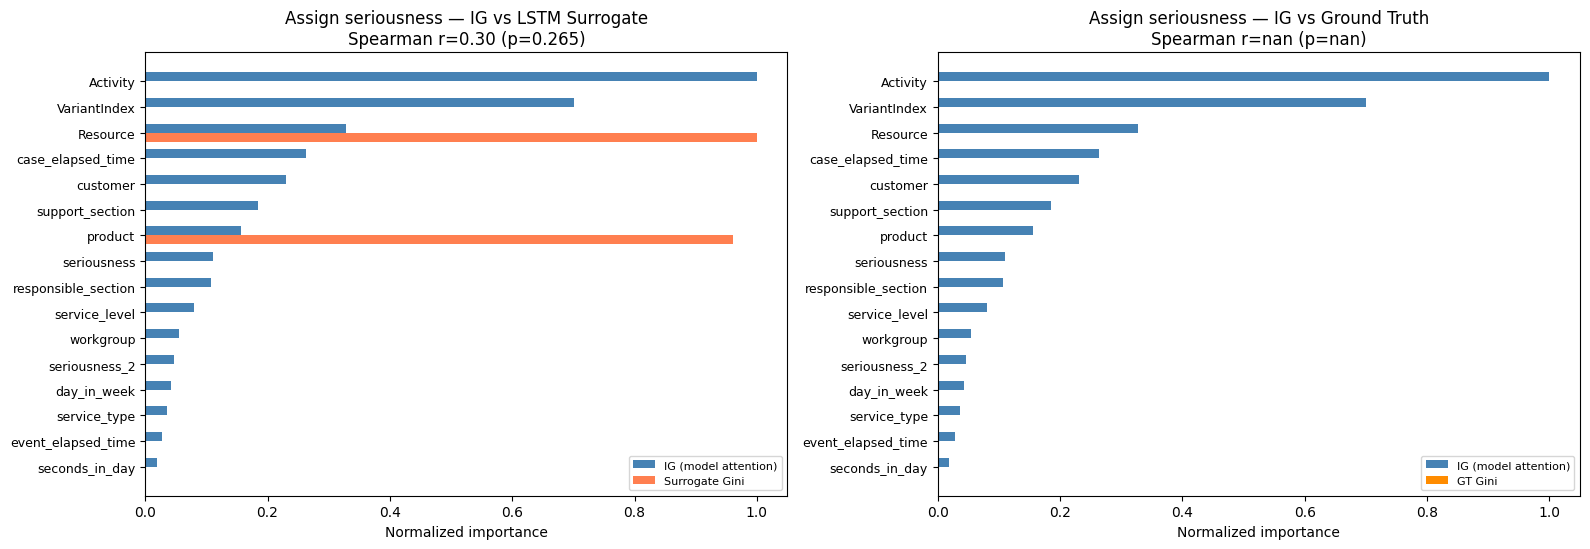


Assign seriousness — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,Activity,0.3285,0.0000,0.0
2,VariantIndex,0.2302,0.0000,0.0
1,Resource,0.1076,0.0219,0.0
12,case_elapsed_time,0.0864,0.0000,0.0
4,customer,0.0756,0.0000,0.0
10,support_section,0.0608,0.0000,0.0
5,product,0.0513,0.0210,0.0
3,seriousness,0.0363,0.0000,0.0
6,responsible_section,0.0351,0.0000,0.0
8,service_level,0.0262,0.0000,0.0


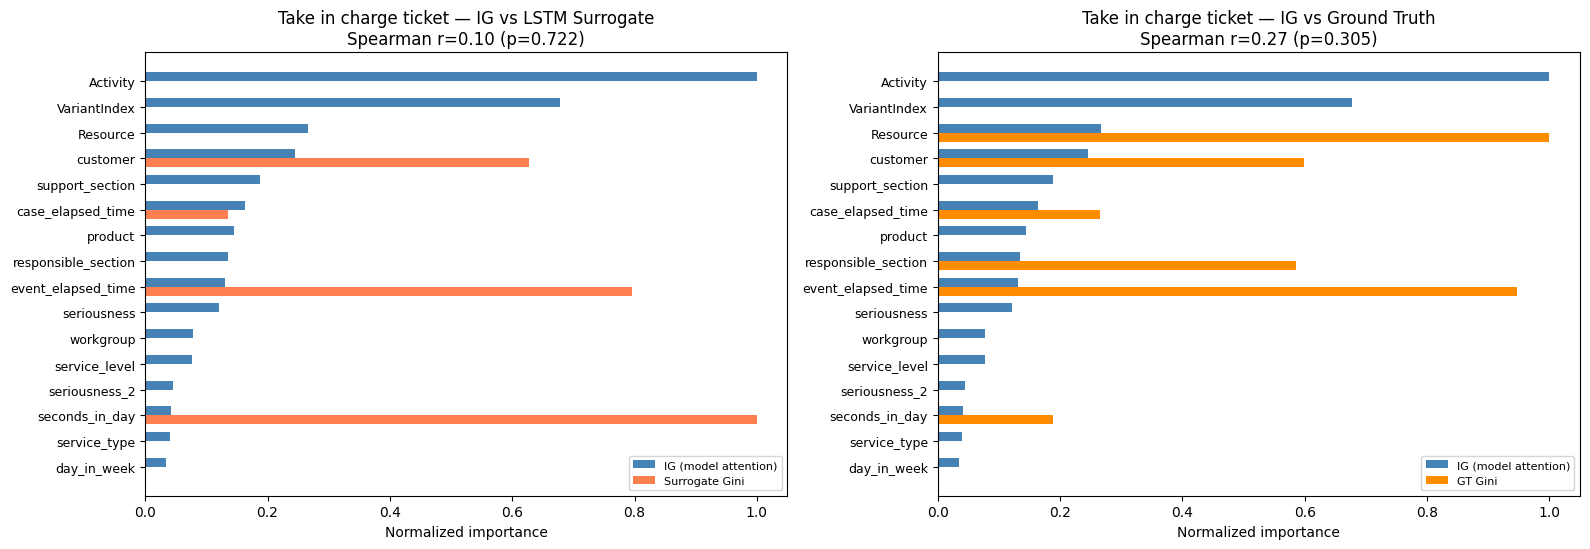


Take in charge ticket — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,Activity,0.8527,0.0000,0.0000
2,VariantIndex,0.5779,0.0000,0.0000
1,Resource,0.2270,0.0000,0.1647
4,customer,0.2093,0.0245,0.0985
10,support_section,0.1606,0.0000,0.0000
12,case_elapsed_time,0.1398,0.0053,0.0437
5,product,0.1232,0.0000,0.0000
6,responsible_section,0.1150,0.0000,0.0966
13,event_elapsed_time,0.1117,0.0311,0.1561
3,seriousness,0.1029,0.0000,0.0000


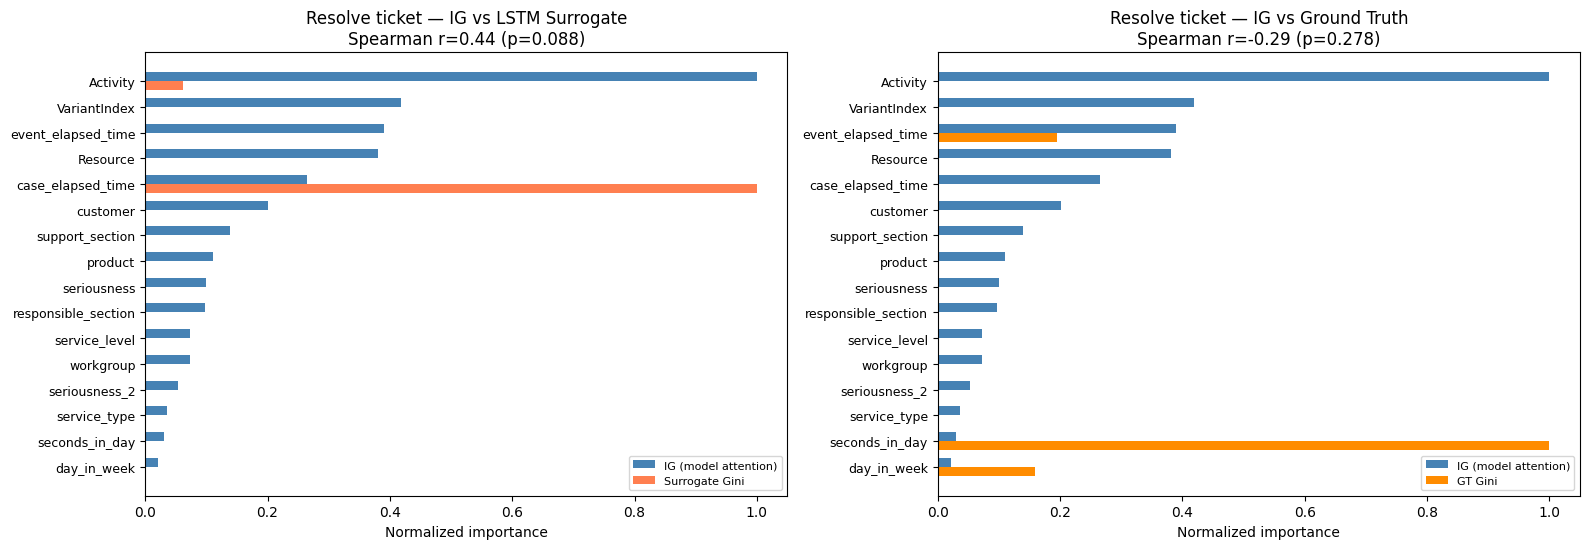


Resolve ticket — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,Activity,0.3037,0.0345,0.0000
2,VariantIndex,0.1271,0.0000,0.0000
13,event_elapsed_time,0.1184,0.0000,0.0276
1,Resource,0.1157,0.0000,0.0000
12,case_elapsed_time,0.0805,0.5647,0.0000
4,customer,0.0611,0.0000,0.0000
10,support_section,0.0423,0.0000,0.0000
5,product,0.0335,0.0000,0.0000
3,seriousness,0.0304,0.0000,0.0000
6,responsible_section,0.0295,0.0000,0.0000


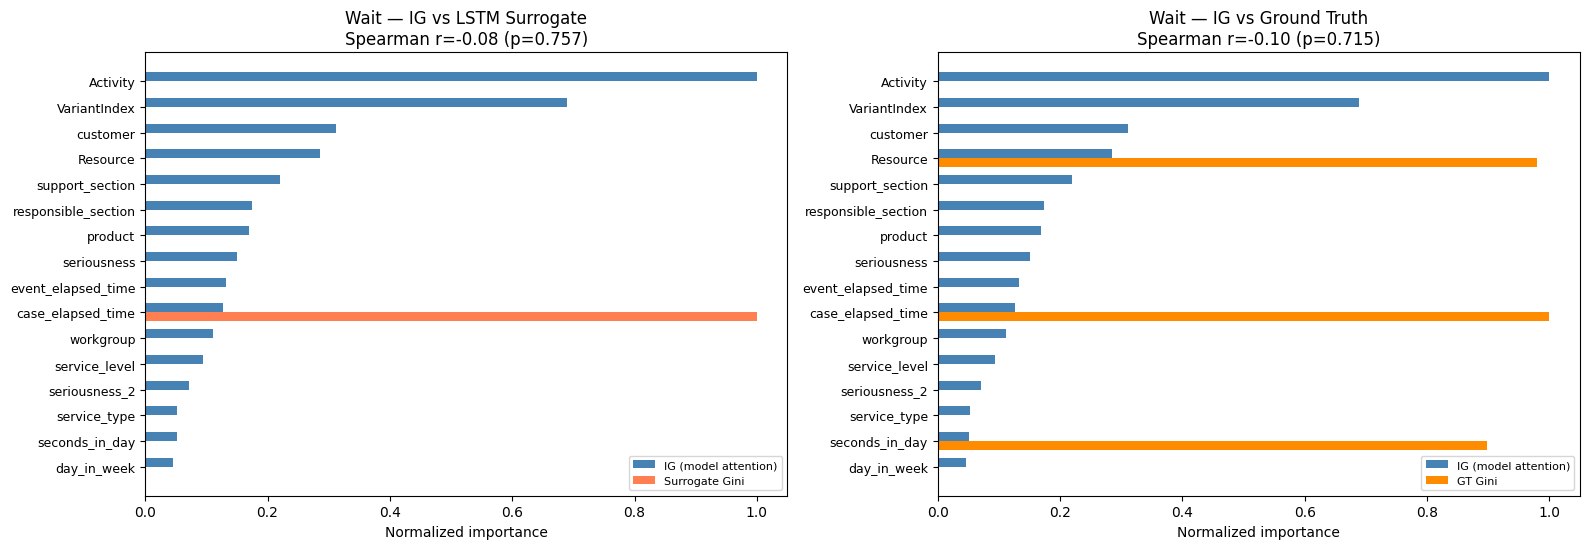


Wait — Feature ranking comparison:


,feature,ig_mean,surrogate_gini,gt_gini
0,Activity,1.0499,0.000,0.0000
2,VariantIndex,0.7237,0.000,0.0000
4,customer,0.3274,0.000,0.0000
1,Resource,0.3000,0.000,0.2639
10,support_section,0.2305,0.000,0.0000
6,responsible_section,0.1827,0.000,0.0000
5,product,0.1773,0.000,0.0000
3,seriousness,0.1579,0.000,0.0000
13,event_elapsed_time,0.1392,0.000,0.0000
12,case_elapsed_time,0.1328,0.051,0.2693


In [6]:
for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    gr = gateway_results[gateway_act]

    ig_features = [f for f in ALL_FEATURES if f in ig_df.columns]
    ig_mean = ig_df[ig_features].mean()

    surr_imp = dict(zip(gr['feature_names'], gr['clf_lstm'].feature_importances_))
    gt_imp = dict(zip(gr['feature_names'], gr['clf_gt'].feature_importances_))

    # Map model input features to surrogate engineered features
    comparison_rows = []
    for feat in ig_features:
        ig_val = ig_mean[feat]

        surr_key = f'last_{feat}' if f'last_{feat}' in surr_imp else feat
        surr_val = surr_imp.get(surr_key, 0.0)
        gt_val = gt_imp.get(surr_key, 0.0)

        # Aggregate related engineered features
        if feat == 'Resource':
            for k in ['last_resource', 'n_unique_resources', 'resource_changed']:
                surr_val = max(surr_val, surr_imp.get(k, 0.0))
                gt_val = max(gt_val, gt_imp.get(k, 0.0))
        if feat == 'case_elapsed_time':
            surr_val = max(surr_val, surr_imp.get('total_elapsed_time', 0.0))
            gt_val = max(gt_val, gt_imp.get('total_elapsed_time', 0.0))
        if feat == 'event_elapsed_time':
            for k in ['last_event_duration', 'mean_event_duration']:
                surr_val = max(surr_val, surr_imp.get(k, 0.0))
                gt_val = max(gt_val, gt_imp.get(k, 0.0))
        if feat == 'Activity':
            for k in ['first_activity', 'n_unique_activities', 'last_activity_repeated']:
                surr_val = max(surr_val, surr_imp.get(k, 0.0))
                gt_val = max(gt_val, gt_imp.get(k, 0.0))

        comparison_rows.append({
            'feature': feat,
            'ig_mean': ig_val,
            'surrogate_gini': surr_val,
            'gt_gini': gt_val,
        })

    comp_df = pd.DataFrame(comparison_rows).sort_values('ig_mean', ascending=False)

    rho_surr, p_surr = spearmanr(comp_df['ig_mean'], comp_df['surrogate_gini'])
    rho_gt, p_gt = spearmanr(comp_df['ig_mean'], comp_df['gt_gini'])

    # --- Plot ---
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(comp_df) * 0.35)))
    y_pos = np.arange(len(comp_df))
    bar_h = 0.35

    def safe_norm(arr):
        m = arr.max()
        return arr / m if m > 0 else arr

    ig_norm = safe_norm(comp_df['ig_mean'].values)
    surr_norm = safe_norm(comp_df['surrogate_gini'].values)
    gt_norm = safe_norm(comp_df['gt_gini'].values)

    ax = axes[0]
    ax.barh(y_pos - bar_h / 2, ig_norm, bar_h, label='IG (model attention)', color='steelblue')
    ax.barh(y_pos + bar_h / 2, surr_norm, bar_h, label='Surrogate Gini', color='coral')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(comp_df['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Normalized importance')
    ax.set_title(f'{gateway_act} — IG vs LSTM Surrogate\n'
                 f'Spearman r={rho_surr:.2f} (p={p_surr:.3f})')
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.barh(y_pos - bar_h / 2, ig_norm, bar_h, label='IG (model attention)', color='steelblue')
    ax.barh(y_pos + bar_h / 2, gt_norm, bar_h, label='GT Gini', color='darkorange')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(comp_df['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Normalized importance')
    ax.set_title(f'{gateway_act} — IG vs Ground Truth\n'
                 f'Spearman r={rho_gt:.2f} (p={p_gt:.3f})')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f'\n{gateway_act} — Feature ranking comparison:')
    display(comp_df.round(4))

## IG attribution: correct vs incorrect predictions

When the LSTM gets the gateway wrong, which features is it over- or
under-weighting compared to when it gets it right?

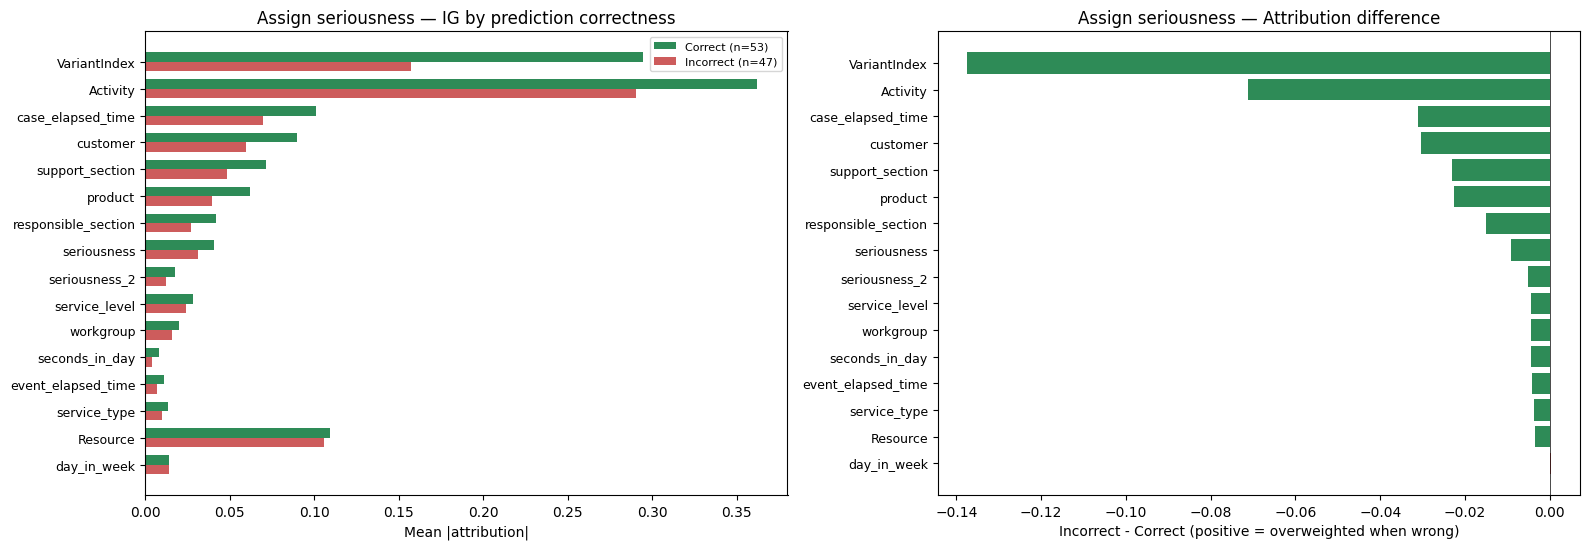

  Overweighted when wrong: day_in_week (+0.0002)
  Underweighted when wrong: VariantIndex (-0.1375), Activity (-0.0713), case_elapsed_time (-0.0310)


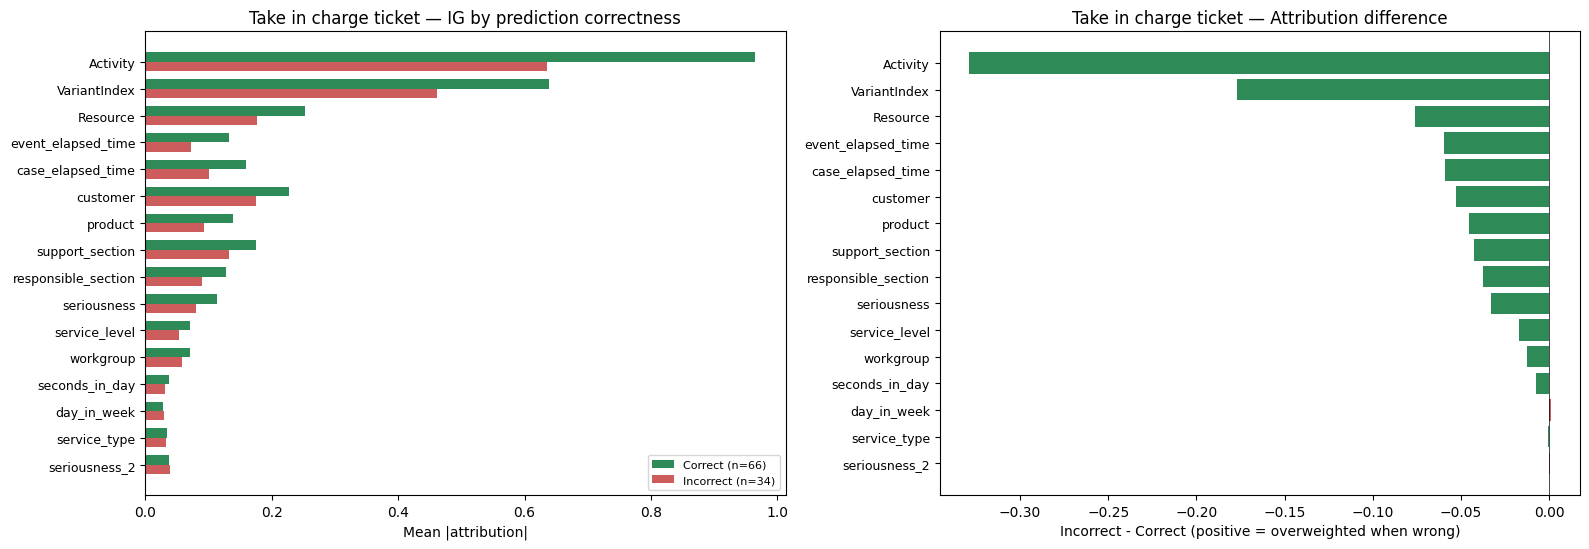

  Overweighted when wrong: day_in_week (+0.0010), seriousness_2 (+0.0006)
  Underweighted when wrong: Activity (-0.3291), VariantIndex (-0.1769), Resource (-0.0758)


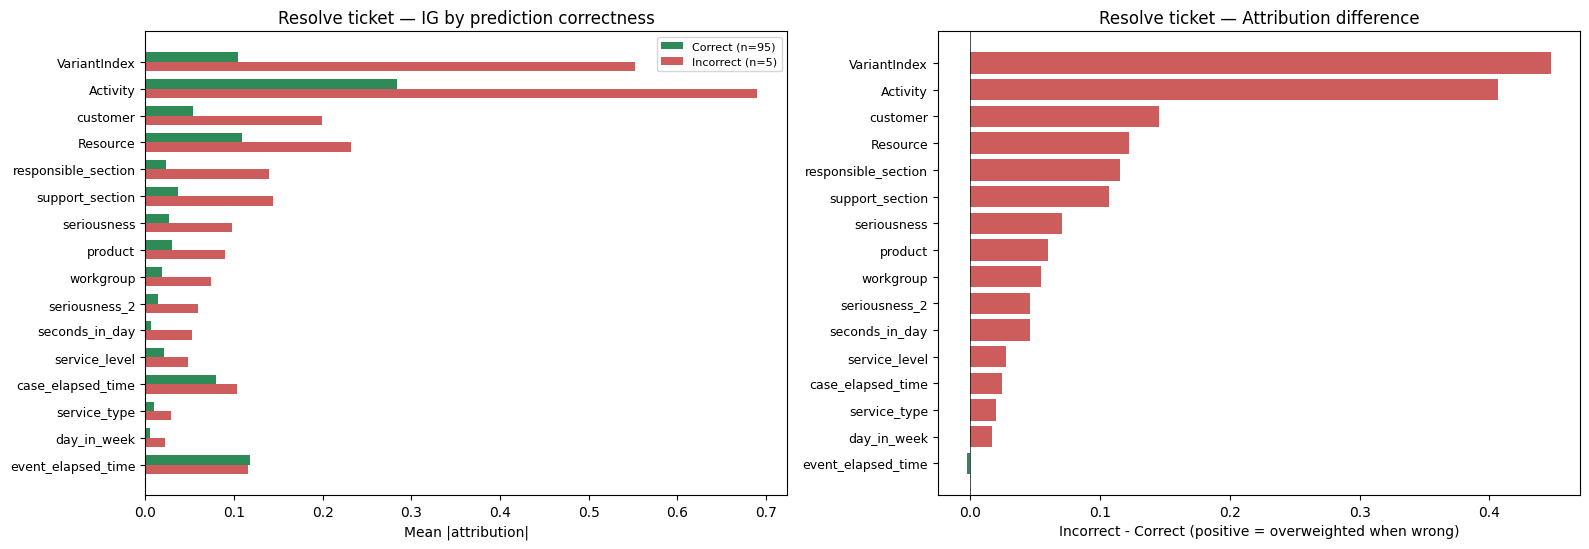

  Overweighted when wrong: VariantIndex (+0.4474), Activity (+0.4064), customer (+0.1451)
  Underweighted when wrong: event_elapsed_time (-0.0027)


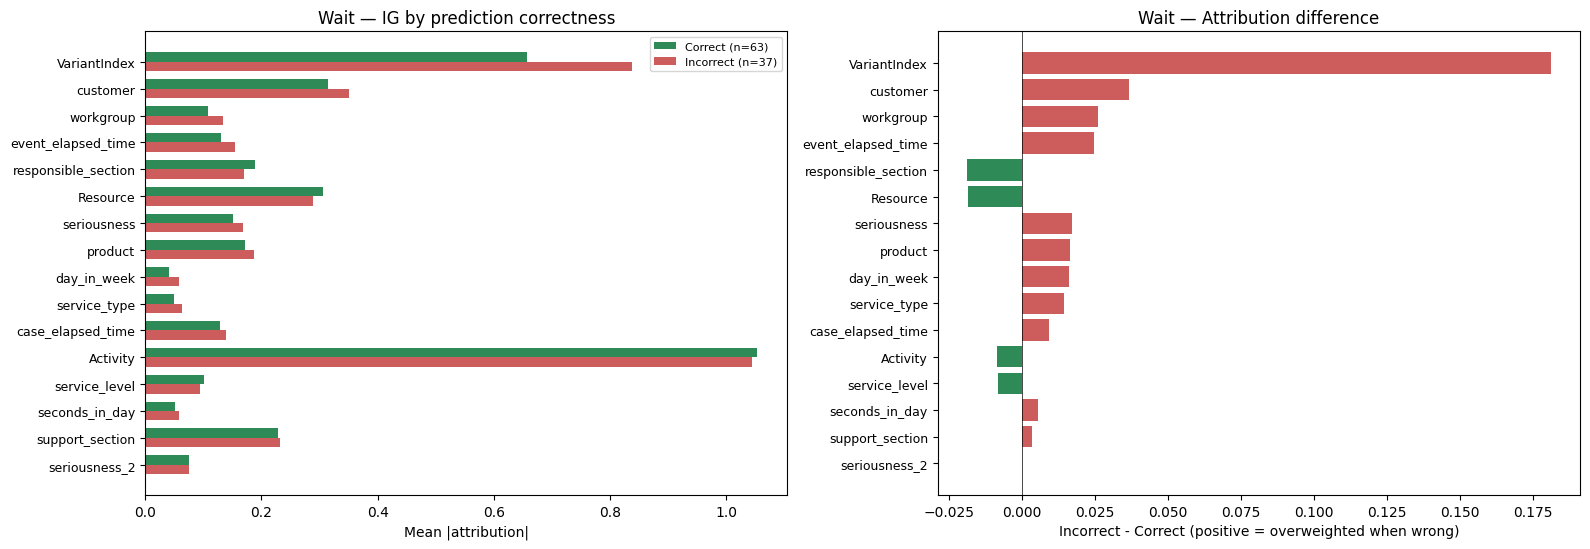

  Overweighted when wrong: VariantIndex (+0.1812), customer (+0.0366), workgroup (+0.0260)
  Underweighted when wrong: responsible_section (-0.0188), Resource (-0.0186), Activity (-0.0085)


In [7]:
for gateway_act in ig_results:
    ig_df = ig_results[gateway_act]
    ig_features = [f for f in ALL_FEATURES if f in ig_df.columns]

    correct = ig_df[ig_df['y_lstm'] == ig_df['y_actual']]
    incorrect = ig_df[ig_df['y_lstm'] != ig_df['y_actual']]

    if len(incorrect) < 3:
        print(f'{gateway_act}: only {len(incorrect)} incorrect predictions, skipping')
        continue

    mean_correct = correct[ig_features].mean()
    mean_incorrect = incorrect[ig_features].mean()

    diff = mean_incorrect - mean_correct
    order = diff.abs().sort_values(ascending=False).index
    mean_correct = mean_correct[order]
    mean_incorrect = mean_incorrect[order]
    diff = diff[order]

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(ig_features) * 0.35)))

    y_pos = np.arange(len(order))
    bar_h = 0.35
    ax = axes[0]
    ax.barh(y_pos - bar_h / 2, mean_correct.values, bar_h,
            label=f'Correct (n={len(correct)})', color='seagreen')
    ax.barh(y_pos + bar_h / 2, mean_incorrect.values, bar_h,
            label=f'Incorrect (n={len(incorrect)})', color='indianred')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |attribution|')
    ax.set_title(f'{gateway_act} — IG by prediction correctness')
    ax.legend(fontsize=8)

    ax = axes[1]
    colors = ['indianred' if d > 0 else 'seagreen' for d in diff.values]
    ax.barh(y_pos, diff.values, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Incorrect - Correct (positive = overweighted when wrong)')
    ax.set_title(f'{gateway_act} — Attribution difference')

    plt.tight_layout()
    plt.show()

    top_over = diff[diff > 0].head(3)
    top_under = diff[diff < 0].head(3)
    if len(top_over) > 0:
        print(f'  Overweighted when wrong: {", ".join(f"{f} (+{v:.4f})" for f, v in top_over.items())}')
    if len(top_under) > 0:
        print(f'  Underweighted when wrong: {", ".join(f"{f} ({v:.4f})" for f, v in top_under.items())}')